In [3]:
import os
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']
proxy = 'http://127.0.0.1:7890'  # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

排序用 down_time = 触发时间（若存在）否则最低点时间；并输出两种时间：
   ticker              sector              trigger_time  trigger_ret  \
0     XLP        必需消费 Staples                       NaT          NaN   
1     XLI      工业 Industrials 2025-11-20 11:35:00-05:00    -0.002494   
2     XLC    通信 Communication 2025-11-20 11:55:00-05:00    -0.002653   
3     XLF       金融 Financials 2025-11-20 11:55:00-05:00    -0.002424   
4     XLV      医疗 Health Care 2025-11-20 11:55:00-05:00    -0.003742   
5     XLK       科技 Technology                       NaT          NaN   
6    XLRE      地产 Real Estate 2025-11-20 15:55:00-05:00    -0.003332   
7     XLY  可选消费 Discretionary                       NaT          NaN   
8     XLB        材料 Materials                       NaT          NaN   
9     XLE           能源 Energy                       NaT          NaN   
10    XLU      公用事业 Utilities                       NaT          NaN   

                    min_time   min_ret                 down_time   down_method  
0  2025-11-2

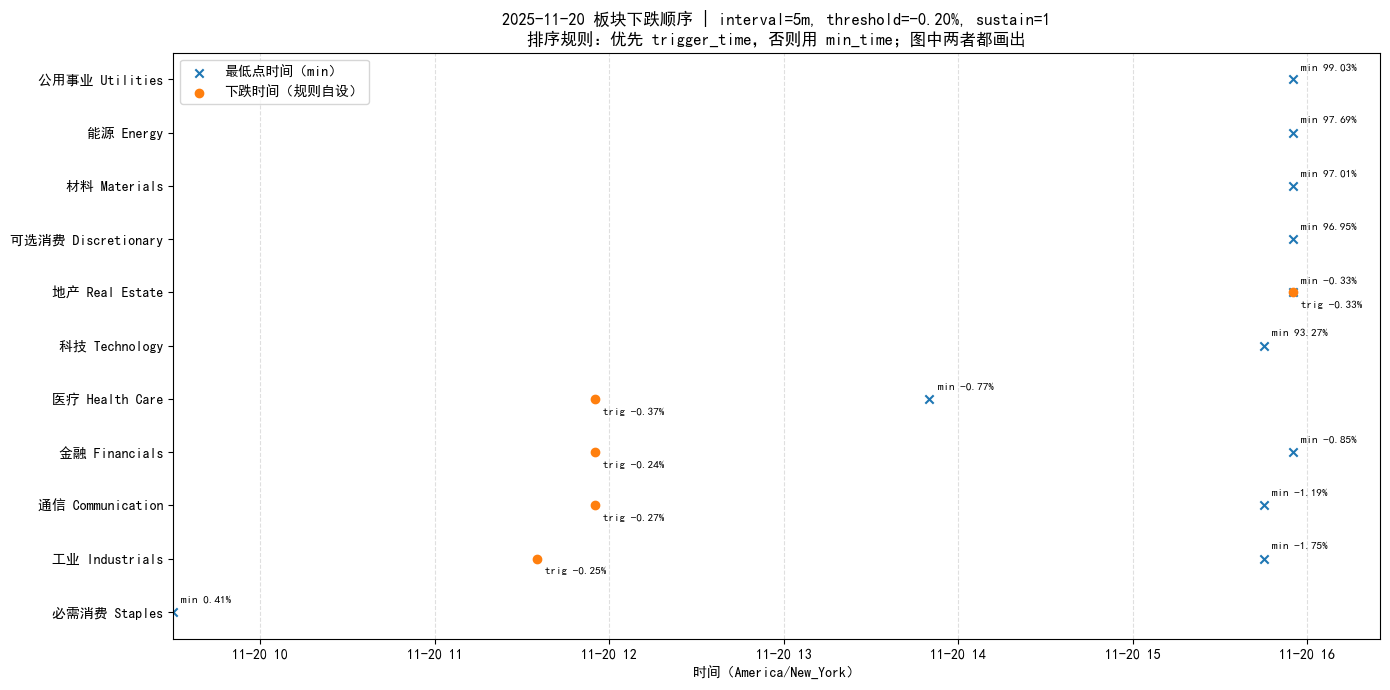

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------
# 参数
# -----------------------------
DATE = "2025-11-20"
INTERVAL = "5m"

THRESHOLD = -0.002     # -0.2%
SUSTAIN_BARS = 1       # 连续N根bar都满足才算触发

INCLUDE_SPY = False    # 是否加入SPY做对照（可选）

sector_etfs = {
    "XLB": "材料 Materials",
    "XLC": "通信 Communication",
    "XLE": "能源 Energy",
    "XLF": "金融 Financials",
    "XLI": "工业 Industrials",
    "XLK": "科技 Technology",
    "XLP": "必需消费 Staples",
    "XLRE":"地产 Real Estate",
    "XLU": "公用事业 Utilities",
    "XLV": "医疗 Health Care",
    "XLY": "可选消费 Discretionary",
}
if INCLUDE_SPY:
    sector_etfs["SPY"] = "大盘 SPY"

tickers = list(sector_etfs.keys())
date_ts = pd.Timestamp(DATE)

# -----------------------------
# 工具函数
# -----------------------------
def _to_ny(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """把yfinance返回的时间戳转换到美东时间（America/New_York）"""
    if idx.tz is None:
        # 有些环境yfinance会给naive index；通常可视作UTC再转
        idx = idx.tz_localize("UTC")
    return idx.tz_convert("America/New_York")

def _between_rth(px: pd.Series) -> pd.Series:
    """仅保留常规交易时段 09:30-16:00（左闭右开；兼容不同pandas版本）"""
    try:
        return px.between_time("09:30", "16:00", inclusive="left")
    except TypeError:
        return px.between_time("09:30", "16:00")

def first_sustained_hit(ret: pd.Series, threshold: float, bars: int) -> pd.Timestamp:
    """
    首次满足 ret<=threshold 且连续 bars 根都满足 的时间点
    返回“满足窗口的最后一根bar”的时间戳
    """
    if ret.empty:
        return pd.NaT
    mask = (ret <= threshold)
    if bars <= 1:
        return mask[mask].index[0] if mask.any() else pd.NaT
    hit = mask.rolling(bars).sum() >= bars
    return hit[hit].index[0] if hit.any() else pd.NaT

# -----------------------------
# 1) 取前收盘（取 DATE 之前最后一个交易日的 Close）
# -----------------------------
daily = yf.download(
    tickers=" ".join(tickers),
    start=(date_ts - pd.Timedelta(days=10)).strftime("%Y-%m-%d"),
    end=(date_ts + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

prev_close = {}
for t in tickers:
    df = daily[t] if isinstance(daily.columns, pd.MultiIndex) else daily
    s = df["Close"].dropna()
    s = s[s.index < date_ts]
    prev_close[t] = float(s.iloc[-1]) if len(s) else np.nan

# -----------------------------
# 2) 取日内分钟线
# -----------------------------
intraday = yf.download(
    tickers=" ".join(tickers),
    start=DATE,
    end=(date_ts + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),  # 右开区间到次日
    interval=INTERVAL,
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

open_dt  = pd.Timestamp(f"{DATE} 09:30", tz="America/New_York")
close_dt = pd.Timestamp(f"{DATE} 16:00", tz="America/New_York")

# -----------------------------
# 3) 计算：trigger_time（阈值触发） + min_time（最低点时间）
#    排序用 down_time：优先 trigger_time，否则 min_time
# -----------------------------
rows = []
for t in tickers:
    pc = prev_close.get(t, np.nan)
    if np.isnan(pc):
        rows.append({
            "ticker": t, "sector": sector_etfs[t],
            "trigger_time": pd.NaT, "trigger_ret": np.nan,
            "min_time": pd.NaT, "min_ret": np.nan,
            "down_time": pd.NaT, "down_method": "no_prev_close"
        })
        continue

    df = intraday[t] if isinstance(intraday.columns, pd.MultiIndex) else intraday
    if "Close" not in df.columns:
        rows.append({
            "ticker": t, "sector": sector_etfs[t],
            "trigger_time": pd.NaT, "trigger_ret": np.nan,
            "min_time": pd.NaT, "min_ret": np.nan,
            "down_time": pd.NaT, "down_method": "no_close_col"
        })
        continue

    px = df["Close"].dropna()
    if px.empty:
        rows.append({
            "ticker": t, "sector": sector_etfs[t],
            "trigger_time": pd.NaT, "trigger_ret": np.nan,
            "min_time": pd.NaT, "min_ret": np.nan,
            "down_time": pd.NaT, "down_method": "no_intraday"
        })
        continue

    px.index = _to_ny(px.index)
    px = _between_rth(px)
    if px.empty:
        rows.append({
            "ticker": t, "sector": sector_etfs[t],
            "trigger_time": pd.NaT, "trigger_ret": np.nan,
            "min_time": pd.NaT, "min_ret": np.nan,
            "down_time": pd.NaT, "down_method": "no_rth_data"
        })
        continue

    ret = px / pc - 1.0

    # 永远存在：最低点时间（ret非空时）
    min_time = ret.idxmin()
    min_ret  = float(ret.loc[min_time])

    # 可能不存在：阈值触发时间
    trigger_time = first_sustained_hit(ret, THRESHOLD, SUSTAIN_BARS)
    if pd.notna(trigger_time):
        trigger_ret = float(ret.loc[trigger_time])
        down_time = trigger_time
        down_method = "threshold"
    else:
        trigger_ret = np.nan
        down_time = min_time
        down_method = "fallback_min"

    rows.append({
        "ticker": t, "sector": sector_etfs[t],
        "trigger_time": trigger_time, "trigger_ret": trigger_ret,
        "min_time": min_time, "min_ret": min_ret,
        "down_time": down_time, "down_method": down_method
    })

result = pd.DataFrame(rows)
result = result.sort_values(["down_time", "min_ret"], na_position="last").reset_index(drop=True)

print("排序用 down_time = 触发时间（若存在）否则最低点时间；并输出两种时间：")
print(result[["ticker","sector","trigger_time","trigger_ret","min_time","min_ret","down_time","down_method"]])

# -----------------------------
# 4) 画图：两种时间都画 + 文字不重叠（annotate + 像素偏移）
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 7))
y = np.arange(len(result))

# 最低点：所有行业都画（橙叉）
ax.scatter(result["min_time"], y, marker="x", label="最低点时间（min）")

# 触发点：有触发的才画（蓝圆）
m_trig = result["trigger_time"].notna()
ax.scatter(result.loc[m_trig, "trigger_time"], y[m_trig], marker="o", label="下跌时间（规则自设）")

ax.set_yticks(y)
ax.set_yticklabels(result["sector"])

# 给右侧留白，避免靠近16:00的文字被裁切
ax.set_xlim(open_dt, close_dt + pd.Timedelta(minutes=25))

ax.set_xlabel("时间（America/New_York）")
ax.set_title(
    f"{DATE} 板块下跌顺序 | interval={INTERVAL}, threshold={THRESHOLD*100:.2f}%, sustain={SUSTAIN_BARS}\n"
    f"排序规则：优先 trigger_time，否则用 min_time；图中两者都画出"
)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
ax.legend()

# 标注：统一为收益率%，并用像素偏移避免重叠
for i, row in result.iterrows():
    # 触发点标注：放右下
    if pd.notna(row["trigger_time"]):
        ax.annotate(
            f"trig {row['trigger_ret']*100:.2f}%",
            xy=(row["trigger_time"], i),
            xytext=(6, -6), textcoords="offset points",
            fontsize=8, ha="left", va="top"
        )

    # 最低点标注：放右上（所有行业都有）
    ax.annotate(
        f"min {row['min_ret']*100:.2f}%",
        xy=(row["min_time"], i),
        xytext=(6, 6), textcoords="offset points",
        fontsize=8, ha="left", va="bottom"
    )

plt.tight_layout()
plt.show()
